# Notebook 11: Statistical Tests

**Sprint 2: Statistics & Mathematics for AI/ML Engineers**

---

## What are Statistical Tests?

A statistical test is a ready-made procedure for hypothesis testing (Notebook 10). It takes the sample data, calculates a **test statistic** (t, Z, chi-square, F, U, W) and a **p-value**, and helps us decide whether to reject H0.

**Analogy:** Different medical tests are used for different problems: a blood test, an X-ray, an ECG. Similarly, different statistical tests are used for different data types and questions. Choosing the wrong test gives a wrong answer.

**Why it matters in AI/ML:** A/B testing, comparing two models, checking whether a categorical feature is related to the target, checking whether the data is normal before choosing a method, and detecting data drift all use these tests.

**Tests covered:** T-Test, Z-Test, Chi-Square Test, ANOVA, Mann-Whitney U Test, Shapiro-Wilk Test.

## Quick Guide: Which Test to Use?

| Question | Data | Test |
|---|---|---|
| Is the mean different from a known value? | Numeric, large n, sigma known | **Z-test** |
| Is the mean different from a known value? | Numeric, sigma unknown or small n | **One-sample t-test** |
| Are two group means different? | Numeric, roughly normal | **Independent t-test** |
| Did the same subjects change (before / after)? | Numeric, paired | **Paired t-test** |
| Are three or more group means different? | Numeric, roughly normal | **ANOVA** |
| Are two groups different? | Numeric, NOT normal / ordinal / outliers | **Mann-Whitney U** |
| Are two categorical variables related? | Categorical counts | **Chi-square** |
| Is my data normally distributed? | Numeric | **Shapiro-Wilk** |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
alpha = 0.05

## 1. T-Test

**Definition:** A t-test compares **means** when the population standard deviation is **unknown** (we estimate it from the sample). It uses the t-distribution, which has heavier tails than the normal distribution to account for the extra uncertainty in small samples. As the sample size grows, the t-distribution becomes almost the same as the normal distribution.

**Three types:**

| Type | Question | H0 |
|---|---|---|
| One-sample | Is the sample mean different from a known value? | mu = mu0 |
| Independent two-sample | Are the means of two separate groups different? | mu1 = mu2 |
| Paired | Is the mean change in the same subjects different from 0? | mean difference = 0 |

**Formulas:**

One-sample:

$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}, \quad df = n - 1$$

Independent (Welch, does not assume equal variances):

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

Paired (d = after - before):

$$t = \frac{\bar{d}}{s_d / \sqrt{n}}, \quad df = n - 1$$

**Assumptions:**
- Data is continuous (interval or ratio)
- Observations are independent (except in the paired test, where pairs are independent)
- Data is roughly normal (important for small n; for n above about 30, the test is fairly robust)
- Independent test: similar variances (the Welch version relaxes this)

**When to use:** Small or medium samples, sigma unknown, comparing one or two means.

**When not to use:**
- Strongly skewed data with a small sample, or heavy outliers (use Mann-Whitney)
- More than two groups (use ANOVA, because many t-tests increase the false-positive rate)
- Categorical data (use chi-square)

**Numerical Example (one-sample):** Delivery times (minutes) of 9 orders: 32, 35, 29, 31, 34, 33, 30, 36, 32. Claim: mean = 30.
Mean = 32.44, s = 2.30, SE = 2.30 / 3 = 0.766
t = (32.44 - 30) / 0.766 = **3.19**, df = 8
The critical value for df = 8 at alpha = 0.05 (two-tailed) is 2.306. Since 3.19 > 2.306, we reject H0 (p is about 0.01).

**Business Example:**
- One-sample: does the average delivery time differ from the promised 30 minutes?
- Independent: do customers who see page A and page B spend different average amounts?
- Paired: did employees' test scores change after a training program (same employees, before and after)?

**AI/ML Example:** Comparing the cross-validation scores of two models (paired t-test on the same folds), and comparing a numeric feature between two classes to see if it can separate them.

ONE-SAMPLE t-test (H0: mean = 30)
Sample mean: 32.44 | SE: 0.766
t (manual): 3.192 | t (scipy): 3.192 | p-value: 0.0128
Decision: Reject H0

INDEPENDENT t-test (H0: mean A = mean B)
Mean A: 67.75 | Mean B: 78.18
t: -5.767 | p-value: 0.0
Decision: Reject H0

PAIRED t-test (H0: mean difference = 0)
Mean change: 4.73
Paired p-value          : 0.0
Wrong (independent) p   : 0.0402 <- usually larger, because pairing is ignored


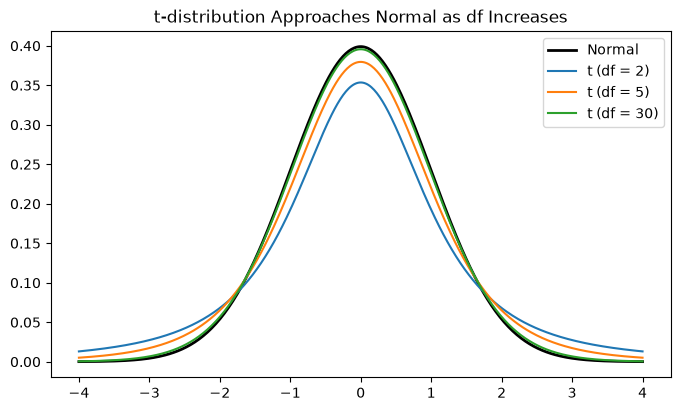

In [2]:
np.random.seed(42)

# ---------- 1. One-sample t-test ----------
delivery = np.array([32, 35, 29, 31, 34, 33, 30, 36, 32])
t1, p1 = stats.ttest_1samp(delivery, popmean=30)

# manual check
n = len(delivery)
se = delivery.std(ddof=1) / np.sqrt(n)
t_manual = (delivery.mean() - 30) / se

print("ONE-SAMPLE t-test (H0: mean = 30)")
print("Sample mean:", round(delivery.mean(), 2), "| SE:", round(se, 3))
print("t (manual):", round(t_manual, 3), "| t (scipy):", round(t1, 3), "| p-value:", round(p1, 4))
print("Decision:", "Reject H0" if p1 < alpha else "Fail to reject H0")

# ---------- 2. Independent two-sample t-test ----------
group_a = np.random.normal(70, 10, 50)    # old page: purchase score
group_b = np.random.normal(78, 10, 50)    # new page
t2, p2 = stats.ttest_ind(group_a, group_b, equal_var=False)   # Welch

print("\nINDEPENDENT t-test (H0: mean A = mean B)")
print("Mean A:", round(group_a.mean(), 2), "| Mean B:", round(group_b.mean(), 2))
print("t:", round(t2, 3), "| p-value:", round(p2, 5))
print("Decision:", "Reject H0" if p2 < alpha else "Fail to reject H0")

# ---------- 3. Paired t-test ----------
before = np.random.normal(60, 8, 30)
after = before + np.random.normal(5, 4, 30)     # same employees, about +5 on average
t3, p3 = stats.ttest_rel(after, before)
t3_wrong, p3_wrong = stats.ttest_ind(after, before, equal_var=False)

print("\nPAIRED t-test (H0: mean difference = 0)")
print("Mean change:", round((after - before).mean(), 2))
print("Paired p-value          :", round(p3, 6))
print("Wrong (independent) p   :", round(p3_wrong, 4), "<- usually larger, because pairing is ignored")

# ---------- t-distribution vs normal ----------
x = np.linspace(-4, 4, 400)
plt.figure(figsize=(8, 4.5))
plt.plot(x, stats.norm.pdf(x), "k", linewidth=2, label="Normal")
for df_ in [2, 5, 30]:
    plt.plot(x, stats.t.pdf(x, df_), label=f"t (df = {df_})")
plt.title("t-distribution Approaches Normal as df Increases")
plt.legend()
plt.show()

**Explanation:** We run all three t-tests. `ttest_1samp` compares one sample with a value, `ttest_ind` compares two independent groups (`equal_var=False` is the Welch version), and `ttest_rel` compares paired measurements. For the first test we also calculate t manually to confirm the formula. The chart compares the t-distribution with the normal distribution.

**Interpretation:**
- **One-sample:** the p-value is below 0.05, so the average delivery time is significantly different from 30 minutes (it is about 32).
- **Independent:** the new page has a clearly higher average, and the p-value is far below 0.05, so the difference is statistically significant.
- **Paired:** the p-value is extremely small because each employee is compared with his or her own earlier score, which removes the person-to-person variation. Using the independent test on paired data gives a larger p-value, so using the **wrong test loses power**.
- **Chart:** for a small df the t-curve has fatter tails, so we need a larger t to reject H0. For df = 30 it is almost the normal curve.

(Your exact numbers can differ slightly from mine. Read your own output and write the interpretation accordingly.)

## 2. Z-Test

**Definition:** A Z-test compares a sample mean (or proportion) with a known value using the **normal distribution**. It is used when the **population standard deviation is known** or the sample is large (n above about 30), so the estimate of sigma is reliable.

**Formulas:**

One-sample Z-test for a mean:

$$Z = \frac{\bar{x} - \mu_0}{\sigma / \sqrt{n}}$$

Z-test for a proportion:

$$Z = \frac{\hat{p} - p_0}{\sqrt{\frac{p_0(1 - p_0)}{n}}}$$

(The two-proportion Z-test for A/B testing was done in Notebook 10.)

**Assumptions:**
- Random, independent sample
- Population sigma is known (or n is large)
- Data is roughly normal, or n is large enough for the Central Limit Theorem to apply

**When to use:** Large samples, known sigma (for example, a well-studied process like IQ scores or machine measurements), A/B tests on proportions with large counts.

**When not to use:** Small samples with unknown sigma (use the t-test), strongly non-normal small samples, categorical variables with more than two categories.

**Numerical Example:** IQ scores in the population have mu = 100 and sigma = 15. A sample of n = 50 students from a coaching class has a mean of 104.
SE = 15 / sqrt(50) = 2.121
Z = (104 - 100) / 2.121 = **1.886**
Two-tailed p-value = about **0.059**
Since 0.059 > 0.05, we **fail to reject H0**: the evidence is not strong enough at 5%.

**Business Example:** A factory knows from history that bottle fill has sigma = 2 ml. After a machine adjustment, 100 bottles are sampled to test whether the mean is still 500 ml.

**AI/ML Example:** A/B testing of conversion rates (Z-test for proportions) with thousands of users, and testing whether a model's accuracy on a large test set differs from a claimed accuracy.

Standard error   : 2.121
Z statistic      : 1.886
Two-tailed p     : 0.0593
Right-tailed p   : 0.0297
Decision (two-tailed, alpha=0.05): Fail to reject H0

Sample proportion: 0.24
Z (proportion)   : 2.0 | p-value: 0.0455
Decision: Reject H0


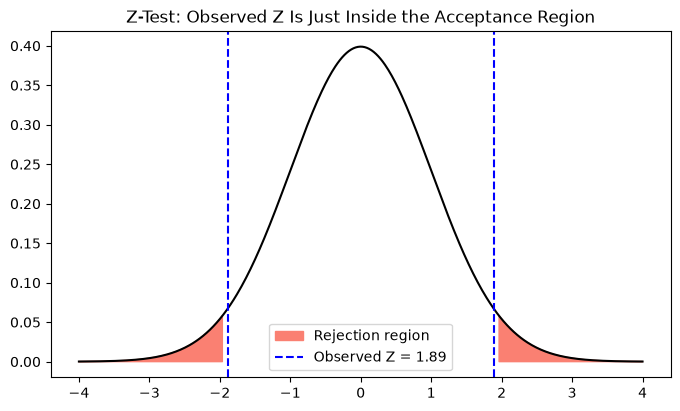

In [3]:
# ---------- Z-test for a mean ----------
mu0, sigma, n, x_bar = 100, 15, 50, 104

se = sigma / np.sqrt(n)
z = (x_bar - mu0) / se
p_two = 2 * (1 - stats.norm.cdf(abs(z)))
p_right = 1 - stats.norm.cdf(z)

print("Standard error   :", round(se, 3))
print("Z statistic      :", round(z, 3))
print("Two-tailed p     :", round(p_two, 4))
print("Right-tailed p   :", round(p_right, 4))
print("Decision (two-tailed, alpha=0.05):", "Reject H0" if p_two < alpha else "Fail to reject H0")

# ---------- Z-test for a proportion ----------
# Claim: 20% of users click an ad. In a sample of 400 users, 96 clicked.
p0, n2, clicks = 0.20, 400, 96
p_hat = clicks / n2
z_prop = (p_hat - p0) / np.sqrt(p0 * (1 - p0) / n2)
p_prop = 2 * (1 - stats.norm.cdf(abs(z_prop)))

print("\nSample proportion:", p_hat)
print("Z (proportion)   :", round(z_prop, 3), "| p-value:", round(p_prop, 4))
print("Decision:", "Reject H0" if p_prop < alpha else "Fail to reject H0")

# ---------- Visualization ----------
x = np.linspace(-4, 4, 500)
plt.figure(figsize=(8, 4.5))
plt.plot(x, stats.norm.pdf(x), "k")
plt.fill_between(x, stats.norm.pdf(x), where=(np.abs(x) >= 1.96), color="salmon", label="Rejection region")
plt.axvline(z, color="blue", linestyle="--", label=f"Observed Z = {z:.2f}")
plt.axvline(-z, color="blue", linestyle="--")
plt.title("Z-Test: Observed Z Is Just Inside the Acceptance Region")
plt.legend()
plt.show()

**Explanation:** We convert the sample mean into a Z score using the known sigma, and then into a p-value with the normal CDF. The second part does the same for a proportion. The chart shows the observed Z against the rejection region (|Z| above 1.96).

**Interpretation:**
- **Mean test:** Z = 1.886 and the two-tailed p is about 0.059, which is slightly above 0.05, so we fail to reject H0. The coaching class average (104) is higher, but with n = 50 the evidence is not strong enough. The right-tailed p is about 0.03, which would reject. This shows why the choice of one-tailed or two-tailed must be made **before** seeing the data.
- **Proportion test:** the observed click rate is 24%, compared with the claimed 20%. The p-value is below 0.05, so the claim is rejected.
- A result near 0.05 is a **borderline** result, and we should say so honestly.

**T-test vs Z-test:**

| | Z-test | T-test |
|---|---|---|
| Sigma | Known | Unknown (estimated by s) |
| Sample size | Large | Any, mainly small |
| Distribution | Normal | t-distribution (df = n - 1) |
| With large n | Both give almost the same answer | Both give almost the same answer |

## 3. Chi-Square Test

**Definition:** The chi-square test compares **observed counts** with **expected counts** for **categorical** data. A large difference between them gives a large chi-square value and a small p-value.

**Two main types:**

| Type | Question | H0 |
|---|---|---|
| **Goodness of fit** | Does one categorical variable follow an expected distribution? | The data follows the expected distribution |
| **Test of independence** | Are two categorical variables related? | The two variables are independent |

**Formula:**

$$\chi^2 = \sum \frac{(O - E)^2}{E}$$

For independence: E = (row total x column total) / grand total, and df = (rows - 1) x (columns - 1).

**Assumptions:**
- Data is counts (frequencies), not percentages or averages
- Categories are mutually exclusive, and observations are independent
- Expected count in each cell should be at least 5 (a rule of thumb)

**When to use:** Two categorical variables (gender and product choice, ad type and click), checking whether a die or a distribution is fair.

**When not to use:** Numeric data (use t-test or correlation), very small expected counts (use Fisher's exact test), paired or repeated measurements (use McNemar's test).

**Numerical Example (independence):** Ad type vs click

| | Clicked | Not clicked | Total |
|---|---|---|---|
| Email | 60 | 140 | 200 |
| SMS | 90 | 110 | 200 |
| Total | 150 | 250 | 400 |

Expected for each Clicked cell = 200 x 150 / 400 = 75, and for each Not clicked cell = 200 x 250 / 400 = 125.
chi-square = (60-75)^2/75 + (140-125)^2/125 + (90-75)^2/75 + (110-125)^2/125 = 3 + 1.8 + 3 + 1.8 = **9.6**
df = (2-1) x (2-1) = 1. Critical value at 0.05 is 3.84. Since 9.6 > 3.84, p is about 0.002, so we **reject H0**: the click rate depends on the ad type.

**Numerical Example (goodness of fit):** A die is rolled 120 times: observed counts 25, 17, 15, 23, 24, 16. Expected = 20 for each face.
chi-square = (25 + 9 + 25 + 9 + 16 + 16) / 20 = **5.0**, df = 5, critical value = 11.07. Since 5.0 < 11.07, we fail to reject H0: the die looks fair.

**Business Example:** Is customer city related to the product category they buy? Is the number of complaints equally distributed over weekdays?

**AI/ML Example:** **Feature selection for categorical features** (`SelectKBest` with `chi2`): keep categorical features that are most related to the target class. Also used to detect drift in categorical features between training and production data.

Observed:
        Clicked  Not clicked
Email       60          140
SMS         90          110

Expected:
        Clicked  Not clicked
Email     75.0        125.0
SMS       75.0        125.0

chi-square: 9.6 | df: 1 | p-value: 0.0019
Decision: Reject H0 (related)
With Yates' correction -> chi-square: 8.971 | p-value: 0.0027

Die: chi-square = 5.0 | p-value = 0.4159
Decision: Fail to reject H0 (die looks fair)


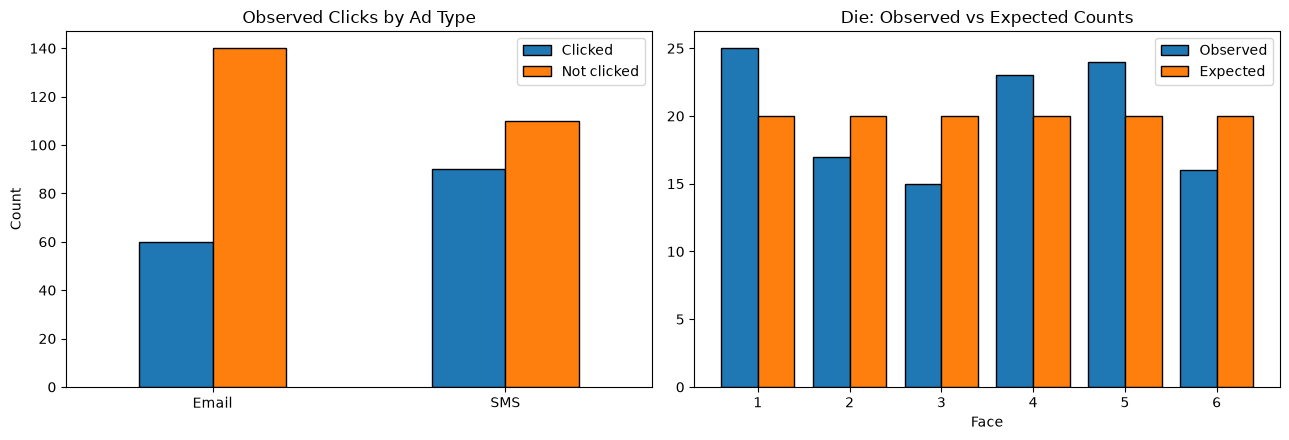

In [4]:
# ---------- Test of independence ----------
observed = np.array([[60, 140],
                     [90, 110]])
table = pd.DataFrame(observed, index=["Email", "SMS"], columns=["Clicked", "Not clicked"])

# correction=False matches the hand calculation (SciPy applies Yates' correction to 2x2 tables by default)
chi2, p, dof, expected = stats.chi2_contingency(observed, correction=False)

print("Observed:\n", table)
print("\nExpected:\n", pd.DataFrame(expected, index=table.index, columns=table.columns).round(1))
print("\nchi-square:", round(chi2, 3), "| df:", dof, "| p-value:", round(p, 4))
print("Decision:", "Reject H0 (related)" if p < alpha else "Fail to reject H0 (independent)")

# with Yates' continuity correction (SciPy default)
chi2_y, p_y, _, _ = stats.chi2_contingency(observed)
print("With Yates' correction -> chi-square:", round(chi2_y, 3), "| p-value:", round(p_y, 4))

# ---------- Goodness of fit: is the die fair? ----------
obs_die = np.array([25, 17, 15, 23, 24, 16])
exp_die = np.full(6, obs_die.sum() / 6)
chi2_g, p_g = stats.chisquare(obs_die, f_exp=exp_die)

print("\nDie: chi-square =", round(chi2_g, 3), "| p-value =", round(p_g, 4))
print("Decision:", "Reject H0 (unfair die)" if p_g < alpha else "Fail to reject H0 (die looks fair)")

# ---------- Visualization ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

table.plot(kind="bar", ax=axes[0], edgecolor="black", rot=0)
axes[0].set_title("Observed Clicks by Ad Type")
axes[0].set_ylabel("Count")

faces = np.arange(1, 7)
axes[1].bar(faces - 0.2, obs_die, width=0.4, label="Observed", edgecolor="black")
axes[1].bar(faces + 0.2, exp_die, width=0.4, label="Expected", edgecolor="black")
axes[1].set_title("Die: Observed vs Expected Counts")
axes[1].set_xlabel("Face")
axes[1].legend()

plt.tight_layout()
plt.show()

**Explanation:** `chi2_contingency` takes a table of observed counts and returns the chi-square value, p-value, degrees of freedom and the expected counts. `chisquare` compares observed counts with expected counts for one variable. We compare the table of observed and expected values, then draw the counts.

**Interpretation:**
- **Independence:** chi-square = 9.6 and p is about 0.002 (below 0.05), so ad type and clicking are **related**. SMS gets a 45% click rate against 30% for email. With Yates' correction the value is slightly lower (about 9.0), but the decision is the same.
- **Die:** chi-square = 5.0 and p is about 0.42, so there is no evidence that the die is unfair. The small differences from 20 are normal random variation.
- A significant chi-square tells us there **is** a relationship, but not how strong it is. To measure strength we use Cramer's V.
- The chi-square test works on **counts**, so never pass percentages to it.

## 4. ANOVA (Analysis of Variance)

**Definition:** One-way ANOVA tests whether the **means of three or more groups** are equal. It compares the variation **between** the groups with the variation **within** the groups.

**Why not many t-tests?** With 3 groups we would need 3 t-tests, and each one carries a 5% false-alarm risk, so the total risk becomes about 14%. ANOVA does one single test and keeps alpha at 5%.

**Formula:**

$$F = \frac{MS_{between}}{MS_{within}} = \frac{SS_{between} / (k - 1)}{SS_{within} / (N - k)}$$

where k = number of groups and N = total observations.

**Hypotheses:**
- H0: mu1 = mu2 = ... = muk (all means are equal)
- H1: at least one mean is different

**Assumptions:**
- The dependent variable is continuous
- Observations are independent
- Each group is roughly normal
- Groups have similar variances (homogeneity of variance)

**When to use:** Comparing the mean of a numeric variable across 3 or more groups.

**When not to use:** Only 2 groups (a t-test is enough), strongly non-normal data or outliers (use the Kruskal-Wallis test), categorical outcomes (use chi-square).

**Important:** ANOVA only says **"at least one group is different"**. To find **which** groups differ, we use a **post-hoc test** such as Tukey's HSD.

**Numerical Example:** Marks under three teaching methods

| Method | Marks | Mean |
|---|---|---|
| A | 70, 75, 80 | 75 |
| B | 80, 85, 90 | 85 |
| C | 90, 95, 100 | 95 |

Grand mean = 85
SS_between = 3 x [(75-85)^2 + (85-85)^2 + (95-85)^2] = 3 x 200 = 600, df = 2, MS_between = 300
SS_within = 50 + 50 + 50 = 150, df = 9 - 3 = 6, MS_within = 25
F = 300 / 25 = **12**. The critical value for F(2, 6) at 0.05 is 5.14, and p is about 0.008, so we **reject H0**: at least one method is different.

**Business Example:** Do the average sales differ across three store layouts? Do customers in four cities spend different amounts?

**AI/ML Example:** **Feature selection** with `f_classif` (ANOVA F-test): for a numeric feature and a categorical target, a high F value means the feature separates the classes well. Also used to compare the scores of three or more models across folds.

Hand example -> F: 12.0 | p-value: 0.008

Store layouts -> F: 23.1 | p-value: 0.0
Decision: Reject H0 (at least one mean differs)

Tukey HSD p-values (rows and columns = layout 1, 2, 3):
[[1.00e+00 3.46e-02 0.00e+00]
 [3.46e-02 1.00e+00 2.00e-04]
 [0.00e+00 2.00e-04 1.00e+00]]

Kruskal-Wallis (non-parametric) p-value: 0.0


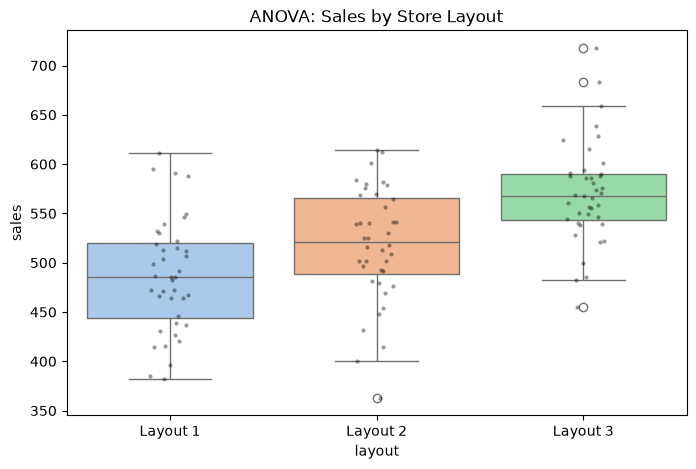

In [5]:
# ---------- Small hand example ----------
A = [70, 75, 80]
B = [80, 85, 90]
C = [90, 95, 100]
f_stat, p_val = stats.f_oneway(A, B, C)
print("Hand example -> F:", round(f_stat, 2), "| p-value:", round(p_val, 4))

# ---------- Larger example: three store layouts ----------
np.random.seed(42)
layout_1 = np.random.normal(500, 60, 40)
layout_2 = np.random.normal(520, 60, 40)
layout_3 = np.random.normal(570, 60, 40)

f_stat, p_val = stats.f_oneway(layout_1, layout_2, layout_3)
print("\nStore layouts -> F:", round(f_stat, 2), "| p-value:", round(p_val, 6))
print("Decision:", "Reject H0 (at least one mean differs)" if p_val < alpha else "Fail to reject H0")

# ---------- Post-hoc: which groups differ? (SciPy 1.8 or newer) ----------
try:
    tukey = stats.tukey_hsd(layout_1, layout_2, layout_3)
    print("\nTukey HSD p-values (rows and columns = layout 1, 2, 3):")
    print(np.round(tukey.pvalue, 4))
except AttributeError:
    print("\nstats.tukey_hsd needs SciPy 1.8+. Run: pip install --upgrade scipy")

# ---------- Non-parametric alternative ----------
h_stat, p_kw = stats.kruskal(layout_1, layout_2, layout_3)
print("\nKruskal-Wallis (non-parametric) p-value:", round(p_kw, 6))

# ---------- Visualization ----------
df_layout = pd.DataFrame({
    "sales": np.concatenate([layout_1, layout_2, layout_3]),
    "layout": ["Layout 1"] * 40 + ["Layout 2"] * 40 + ["Layout 3"] * 40,
})
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_layout, x="layout", y="sales", hue="layout", palette="pastel", legend=False)
sns.stripplot(data=df_layout, x="layout", y="sales", color="black", alpha=0.4, size=3)
plt.title("ANOVA: Sales by Store Layout")
plt.show()

**Explanation:** `f_oneway` runs one-way ANOVA. First we check the hand example, where F is exactly 12. Then we simulate three store layouts with different true means. Because ANOVA only says "somewhere there is a difference", we run **Tukey's HSD** to compare each pair. `kruskal` is the non-parametric alternative. The box plot shows the groups side by side.

**Interpretation:**
- **Hand example:** F = 12 and p is about 0.008, which matches our manual calculation.
- **Store layouts:** the p-value is far below 0.05, so at least one layout has a different average. The box plot shows Layout 3 clearly higher.
- **Tukey table:** pairs with p below 0.05 are significantly different. Layout 3 should differ from the others. The pair Layout 1 vs Layout 2 is closer, so its p-value will be larger. (Read your own table, because the data is random.)
- **Kruskal-Wallis** gives the same conclusion, which adds confidence.
- A large F means the groups differ much more **between** each other than the random variation **inside** each group.

## 5. Mann-Whitney U Test

**Definition:** The Mann-Whitney U test is the **non-parametric alternative to the independent t-test**. It compares two independent groups using **ranks** instead of the actual values, so it does not need normal data. It tests whether values in one group tend to be larger than values in the other (a difference in distribution or median).

**How it works:** Combine both groups, rank all values from smallest to largest, add up the ranks for each group, and compute U.

$$U_1 = R_1 - \frac{n_1(n_1 + 1)}{2}, \qquad U = \min(U_1, U_2)$$

where R1 = sum of ranks of group 1. A very small U (or very large) means the groups are separated.

**Hypotheses:**
- H0: the two groups come from the same distribution (neither tends to be larger)
- H1: one group tends to have larger values

**Assumptions:**
- Two independent groups, independent observations
- Data is at least ordinal (can be ranked)
- For a pure "median comparison", both groups should have a similar shape

**When to use:** Skewed data (income, waiting time, response time), outliers, small samples that are clearly non-normal, ordinal data (star ratings, satisfaction scores).

**When not to use:** Paired data (use the Wilcoxon signed-rank test), 3 or more groups (use Kruskal-Wallis), clean normal data (the t-test has slightly more power).

**Numerical Example:** Group A = 3, 5, 7 and Group B = 6, 8, 10.
Combined ranks: 3(1), 5(2), 6(3), 7(4), 8(5), 10(6)
R_A = 1 + 2 + 4 = 7, so U_A = 7 - 6 = **1**, and U_B = 9 - 1 = 8 (the two U values always add up to n1 x n2 = 9).
The exact two-sided p-value is **0.2**, so we fail to reject H0. With only 3 values per group, even a fairly clear difference cannot be confirmed.

**Business Example:** Customer support response times are heavily right-skewed. Compare the response times of two support teams with Mann-Whitney, because the mean would be dominated by a few very long cases.

**AI/ML Example:** Comparing the distribution of a skewed feature between two classes (for example, transaction amount for fraud vs normal), or comparing model latency of two versions when latency has a long tail.

Hand example -> U: 1.0 | p-value: 0.2

Mean A: 9.43 | Mean B: 18.24
Median A: 5.95 | Median B: 13.91
Mann-Whitney p-value: 0.00124
t-test p-value       : 0.00063
Decision (Mann-Whitney): Reject H0


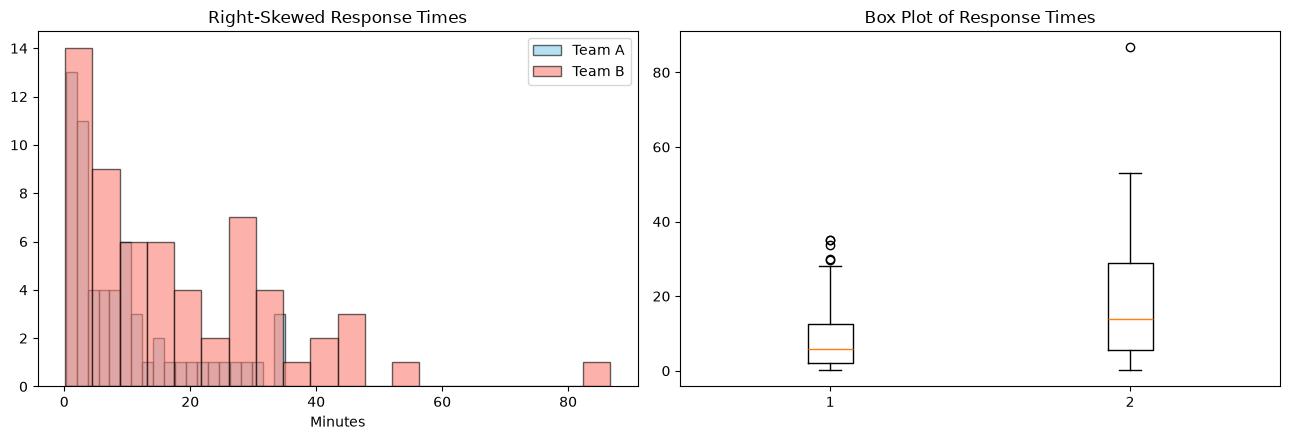

In [6]:
# ---------- Small hand example ----------
a = [3, 5, 7]
b = [6, 8, 10]
u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
print("Hand example -> U:", u, "| p-value:", round(p, 3))

# ---------- Skewed data: response times of two support teams ----------
np.random.seed(42)
team_a = np.random.exponential(scale=10, size=60)
team_b = np.random.exponential(scale=20, size=60)

u2, p_mw = stats.mannwhitneyu(team_a, team_b, alternative="two-sided")
t_stat, p_t = stats.ttest_ind(team_a, team_b, equal_var=False)

print("\nMean A:", round(team_a.mean(), 2), "| Mean B:", round(team_b.mean(), 2))
print("Median A:", round(np.median(team_a), 2), "| Median B:", round(np.median(team_b), 2))
print("Mann-Whitney p-value:", round(p_mw, 5))
print("t-test p-value       :", round(p_t, 5))
print("Decision (Mann-Whitney):", "Reject H0" if p_mw < alpha else "Fail to reject H0")

# ---------- Visualization ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(team_a, bins=20, alpha=0.6, label="Team A", color="skyblue", edgecolor="black")
axes[0].hist(team_b, bins=20, alpha=0.6, label="Team B", color="salmon", edgecolor="black")
axes[0].set_title("Right-Skewed Response Times")
axes[0].set_xlabel("Minutes")
axes[0].legend()

axes[1].boxplot([team_a, team_b], tick_labels=["Team A", "Team B"]) if hasattr(plt, "boxplot") and "tick_labels" in plt.boxplot.__code__.co_varnames else axes[1].boxplot([team_a, team_b])
axes[1].set_title("Box Plot of Response Times")
plt.tight_layout()
plt.show()

**Explanation:** `mannwhitneyu` ranks all values and compares the rank sums of the two groups. First we confirm the hand example (U = 1, p = 0.2). Then we create two skewed groups, run Mann-Whitney and the t-test on the same data, and compare. The histograms show the strong right skew.

**Interpretation:**
- **Hand example:** U = 1 and p = 0.2, which matches our manual work. Tiny samples have low power.
- **Support teams:** the data is strongly right-skewed (long tail), so the mean is pulled up by a few long cases, and the median describes a typical case better. The Mann-Whitney p-value is below 0.05, which means Team B is generally slower than Team A.
- The t-test is also run to compare. When data is skewed, its assumptions are shaky, so we trust Mann-Whitney more.
- If your plot's `boxplot` line shows an error, replace it with `axes[1].boxplot([team_a, team_b])`.

**Mann-Whitney vs t-test:**

| | Independent t-test | Mann-Whitney U |
|---|---|---|
| Compares | Means | Ranks (distributions) |
| Needs normal data | Yes (roughly) | No |
| Outliers | Sensitive | Robust |
| Data type | Continuous | Continuous or ordinal |
| Power on normal data | Slightly higher | Slightly lower |

## 6. Shapiro-Wilk Test

**Definition:** The Shapiro-Wilk test checks whether a sample **comes from a normal distribution**. It compares the sorted sample values with the values we would expect from a perfectly normal sample. The statistic W is between 0 and 1, and values close to 1 mean the data looks normal.

**Hypotheses:**
- H0: the data is normally distributed
- H1: the data is **not** normally distributed

**Decision rule:**
- p-value > 0.05: **fail to reject H0** (no evidence against normality, so normal-based tests are reasonable)
- p-value < 0.05: **reject H0** (the data is not normal, so consider Mann-Whitney / Kruskal-Wallis or a transformation)

Note that here **a large p-value is the "good" result** for someone who wants to use a t-test. This is opposite to what many people expect.

**Assumptions:** continuous data, independent observations.

**When to use:** Before a t-test, ANOVA or Pearson correlation, to check the normality assumption. Also to check whether the residuals of a regression model are normal. It works best for n between about 3 and 5000.

**When not to use / caution:**
- **Large samples:** even a tiny, harmless deviation from normality gives a small p-value. Always combine it with a histogram or Q-Q plot.
- **Small samples:** the test has low power and may miss real non-normality.
- Not suitable for categorical data.

**Business Example:** Before comparing the average order value of two regions with a t-test, check whether the order values are normal. If they are strongly skewed, use Mann-Whitney instead.

**AI/ML Example:** Checking the **residuals of Linear Regression** for normality, deciding whether a feature needs a log transform, and choosing between parametric and non-parametric tests during EDA.

Normal        -> W = 0.9899 | p-value = 0.65517 | looks normal
Right-skewed  -> W = 0.8406 | p-value = 0.00000 | NOT normal
Uniform       -> W = 0.9540 | p-value = 0.00154 | NOT normal


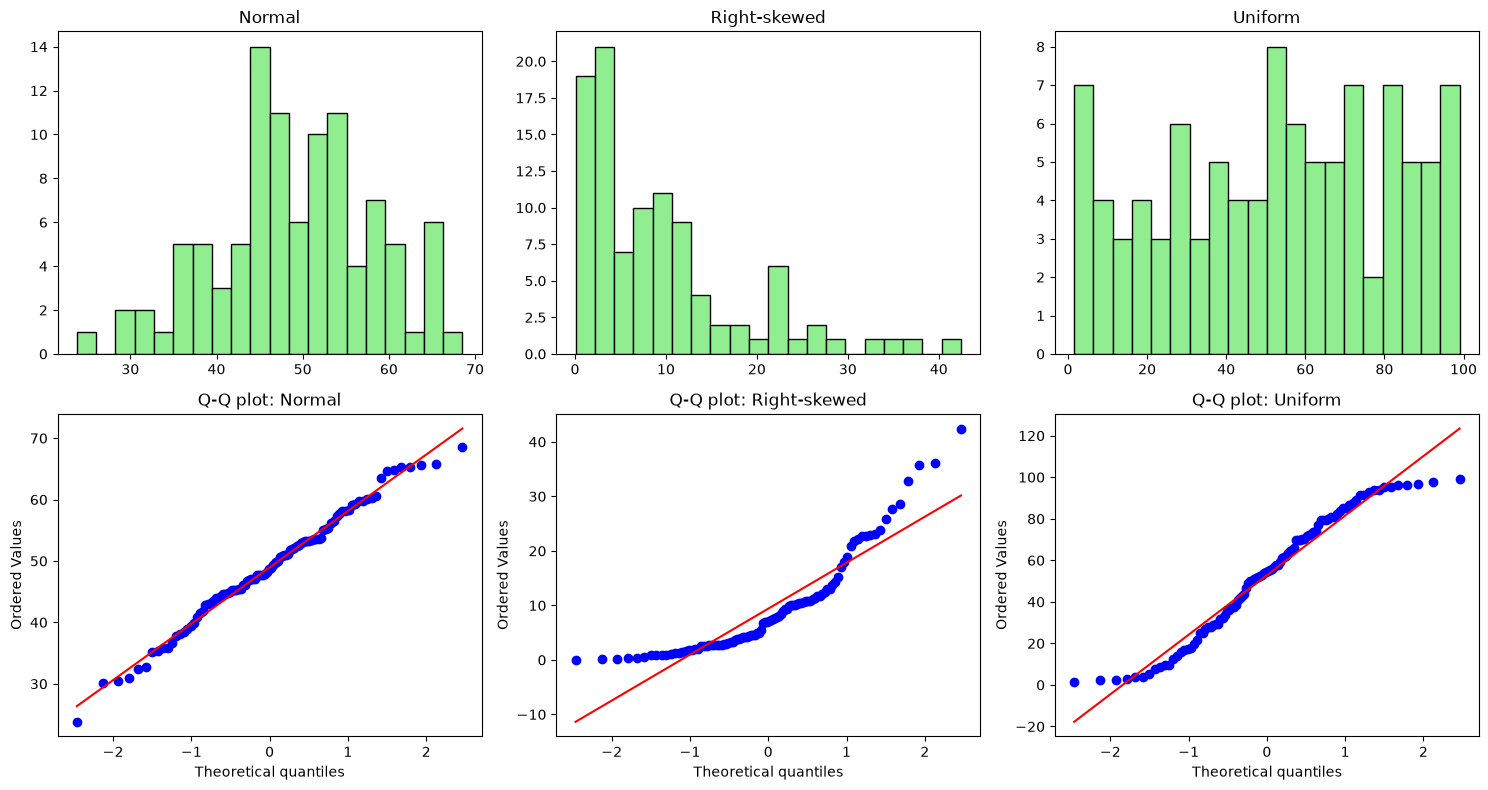


Large almost-normal sample (n = 4000): W = 0.9985 | p-value = 0.0007


In [7]:
np.random.seed(42)

normal_data = np.random.normal(50, 10, 100)
skewed_data = np.random.exponential(scale=10, size=100)
uniform_data = np.random.uniform(0, 100, 100)

datasets = {"Normal": normal_data, "Right-skewed": skewed_data, "Uniform": uniform_data}

for name, d in datasets.items():
    w, p = stats.shapiro(d)
    verdict = "looks normal" if p > alpha else "NOT normal"
    print(f"{name:13s} -> W = {w:.4f} | p-value = {p:.5f} | {verdict}")

# ---------- Histogram + Q-Q plot ----------
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, (name, d) in enumerate(datasets.items()):
    axes[0, i].hist(d, bins=20, color="lightgreen", edgecolor="black")
    axes[0, i].set_title(f"{name}")
    stats.probplot(d, dist="norm", plot=axes[1, i])
    axes[1, i].set_title(f"Q-Q plot: {name}")
plt.tight_layout()
plt.show()

# ---------- Large sample warning: tiny deviation, tiny p-value ----------
big = np.random.standard_t(df=20, size=4000)      # almost normal, slightly heavy tails
w_big, p_big = stats.shapiro(big)
print("\nLarge almost-normal sample (n = 4000): W =", round(w_big, 4), "| p-value =", round(p_big, 4))

**Explanation:** `stats.shapiro()` returns W and the p-value. We test normal, right-skewed and uniform data, then draw a histogram and a Q-Q plot for each. In a **Q-Q plot**, if the points follow the straight red line, the data is normal. The last part tests a very large sample that is almost normal.

**Interpretation:**
- **Normal data:** W is close to 1 and p is usually above 0.05, so there is no evidence against normality. (Even truly normal data fails about 5% of the time, just by chance.)
- **Right-skewed data:** p is far below 0.05, so we reject normality. In the Q-Q plot the points curve away from the line.
- **Uniform data:** it is flat, not bell-shaped, and the test will usually reject normality as well.
- **Large sample:** with thousands of points, even a very slight departure from normal can give p below 0.05, although the t-test would work fine. So **never rely on the p-value alone, and always look at the plot**.

**Workflow:** Shapiro-Wilk (and Q-Q plot) shows normal, so use the t-test or ANOVA. If it shows non-normal, use Mann-Whitney or Kruskal-Wallis, or transform the data (for example log) and test again.

In [8]:
def compare_two_groups(a, b, alpha=0.05):
    """Check normality first, then choose the right test automatically."""
    p_a = stats.shapiro(a).pvalue
    p_b = stats.shapiro(b).pvalue
    both_normal = (p_a > alpha) and (p_b > alpha)

    if both_normal:
        test_name = "Welch t-test"
        p = stats.ttest_ind(a, b, equal_var=False).pvalue
    else:
        test_name = "Mann-Whitney U"
        p = stats.mannwhitneyu(a, b, alternative="two-sided").pvalue

    print(f"Shapiro p-values: group A = {p_a:.4f}, group B = {p_b:.4f}")
    print(f"Chosen test: {test_name} | p-value = {p:.5f}")
    print("Decision:", "Reject H0 (groups differ)" if p < alpha else "Fail to reject H0")

np.random.seed(42)
print("Case 1: normal data")
compare_two_groups(np.random.normal(50, 10, 60), np.random.normal(58, 10, 60))

print("\nCase 2: skewed data")
compare_two_groups(np.random.exponential(10, 60), np.random.exponential(20, 60))

Case 1: normal data
Shapiro p-values: group A = 0.8232, group B = 0.5756
Chosen test: Welch t-test | p-value = 0.00000
Decision: Reject H0 (groups differ)

Case 2: skewed data
Shapiro p-values: group A = 0.0001, group B = 0.0001
Chosen test: Mann-Whitney U | p-value = 0.00000
Decision: Reject H0 (groups differ)


**Explanation:** This function does what a data scientist does in practice: it checks normality with Shapiro-Wilk on both groups, and then picks the Welch t-test (normal) or Mann-Whitney U (not normal).

**Interpretation:** For the normal data, the t-test is chosen. For the skewed data, Shapiro rejects normality, so Mann-Whitney is chosen. This shows how the six tests of this notebook connect: **normality check, then parametric or non-parametric test**.

## Summary

| Test | Compares | Data type | Key assumption | Non-parametric alternative |
|---|---|---|---|---|
| One-sample t-test | Mean vs known value | Numeric | Roughly normal | Wilcoxon signed-rank |
| Independent t-test | 2 group means | Numeric | Roughly normal | Mann-Whitney U |
| Paired t-test | Before vs after | Numeric (paired) | Differences roughly normal | Wilcoxon signed-rank |
| Z-test | Mean or proportion vs known value | Numeric / proportion | Sigma known or large n | - |
| Chi-square | Observed vs expected counts | Categorical | Expected count at least 5 | Fisher's exact |
| ANOVA | 3 or more group means | Numeric | Normal, equal variances | Kruskal-Wallis |
| Mann-Whitney U | 2 groups (ranks) | Numeric / ordinal | Independent groups | - |
| Shapiro-Wilk | Normality of one sample | Numeric | Independent observations | - |

**Quick decision:**
1. Categorical data? **Chi-square**
2. Numeric data, 3 or more groups? **ANOVA** (or Kruskal-Wallis), then a **post-hoc** test
3. Numeric data, 2 groups? Check normality with **Shapiro-Wilk**. Normal: **t-test**. Not normal: **Mann-Whitney U**
4. One sample vs a known value? **Z-test** (sigma known / large n) or **one-sample t-test**

## Advantages
- Give an objective, repeatable way to decide using data
- Each test is designed for a specific data type and question
- Non-parametric tests work when assumptions fail
- Directly useful for A/B testing, feature selection and model comparison

## Limitations
- Wrong test or violated assumptions give misleading p-values
- Significance does not mean practical importance, and large samples make tiny effects significant
- Running many tests increases false positives (use corrections such as Bonferroni)
- Normality tests are over-sensitive with large n and weak with small n
- ANOVA only says "some difference exists" and needs a post-hoc test
- p-values depend on random sampling and independence of observations